In [1]:
# ==========================================================
# MINI PROJECT 5
# HAWKES PROCESS FOR VOLATILITY BURST DETECTION
# PART 1
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from scipy.optimize import minimize

# ==========================================================
# STEP 1 : Upload Dataset
# ==========================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

depth = pd.read_csv(filename)

print("Dataset Shape :", depth.shape)

# ==========================================================
# STEP 2 : Timestamp
# ==========================================================

depth["timestamp"] = pd.to_datetime(depth["timestamp"])

depth = depth.sort_values("timestamp").reset_index(drop=True)

# ==========================================================
# STEP 3 : Mid Price
# ==========================================================

depth["mid_price"] = (
    depth["best_bid"] +
    depth["best_ask"]
) / 2

# ==========================================================
# STEP 4 : Mid-Price Returns
# ==========================================================

depth["return"] = depth["mid_price"].pct_change(fill_method=None)

depth = depth.replace([np.inf, -np.inf], np.nan)

depth = depth.dropna(subset=["return"]).reset_index(drop=True)

print(depth["return"].describe())

# ==========================================================
# STEP 5 : Detect Volatility Burst Events
# ==========================================================

threshold = depth["return"].abs().quantile(0.95)

print("95th Percentile Threshold :", threshold)

depth["volatility_event"] = (
    depth["return"].abs() > threshold
).astype(int)

events = depth[
    depth["volatility_event"] == 1
].copy()

print("Number of Volatility Burst Events :", len(events))

# ==========================================================
# STEP 6 : Event Times
# ==========================================================

event_times = (
    events["timestamp"] -
    depth["timestamp"].iloc[0]
).dt.total_seconds().values

if len(event_times) == 0:
    raise ValueError("No volatility burst events detected.")

T = event_times[-1]

print("Observation Time :", T)

# ==========================================================
# STEP 7 : Recursive Hawkes Log-Likelihood
# ==========================================================

def negative_log_likelihood(params):

    mu, alpha, beta = params

    if mu <= 0 or alpha <= 0 or beta <= 0:
        return np.inf

    n = len(event_times)

    R = np.zeros(n)

    for i in range(1, n):

        dt = event_times[i] - event_times[i-1]

        R[i] = np.exp(-beta * dt) * (1 + R[i-1])

    intensity = mu + alpha * R

    if np.any(intensity <= 0):
        return np.inf

    loglik = np.sum(np.log(intensity))

    compensator = (
        mu * T +
        (alpha / beta) *
        np.sum(
            1 -
            np.exp(
                -beta * (T - event_times)
            )
        )
    )

    return -(loglik - compensator)

# ==========================================================
# STEP 8 : Estimate Hawkes Parameters
# ==========================================================

result = minimize(

    negative_log_likelihood,

    x0=[0.10, 0.20, 1.00],

    method="L-BFGS-B",

    bounds=[
        (1e-6, None),
        (1e-6, None),
        (1e-6, None)
    ]

)

mu_hat, alpha_hat, beta_hat = result.x

print("\n==============================")
print("Optimization Results")
print("==============================")

print("Success :", result.success)
print("Message :", result.message)

print("\nEstimated Parameters")
print("------------------------------")

print(f"μ (Baseline)   : {mu_hat:.6f}")
print(f"α (Excitation) : {alpha_hat:.6f}")
print(f"β (Decay)      : {beta_hat:.6f}")

Saving BTCUSDT_Depth_1Hour.csv to BTCUSDT_Depth_1Hour.csv
Dataset Shape : (35901, 45)
count    31775.000000
mean         0.000561
std          0.035253
min         -0.659559
25%         -0.000037
50%          0.000000
75%          0.000038
max          1.939732
Name: return, dtype: float64
95th Percentile Threshold : 0.004852490167590405
Number of Volatility Burst Events : 1589
Observation Time : 3596.175

Optimization Results
Success : True
Message : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Estimated Parameters
------------------------------
μ (Baseline)   : 0.238287
α (Excitation) : 2.667632
β (Decay)      : 5.784472


Hawkes intensity computed successfully.
Poisson Intensity : 0.44185836340000134
             Metric        Value
0  Number of Events  1589.000000
1  Observation Time  3596.175000
2       Estimated μ     0.238287
3       Estimated α     2.667632
4       Estimated β     5.784472
5         Poisson λ     0.441858


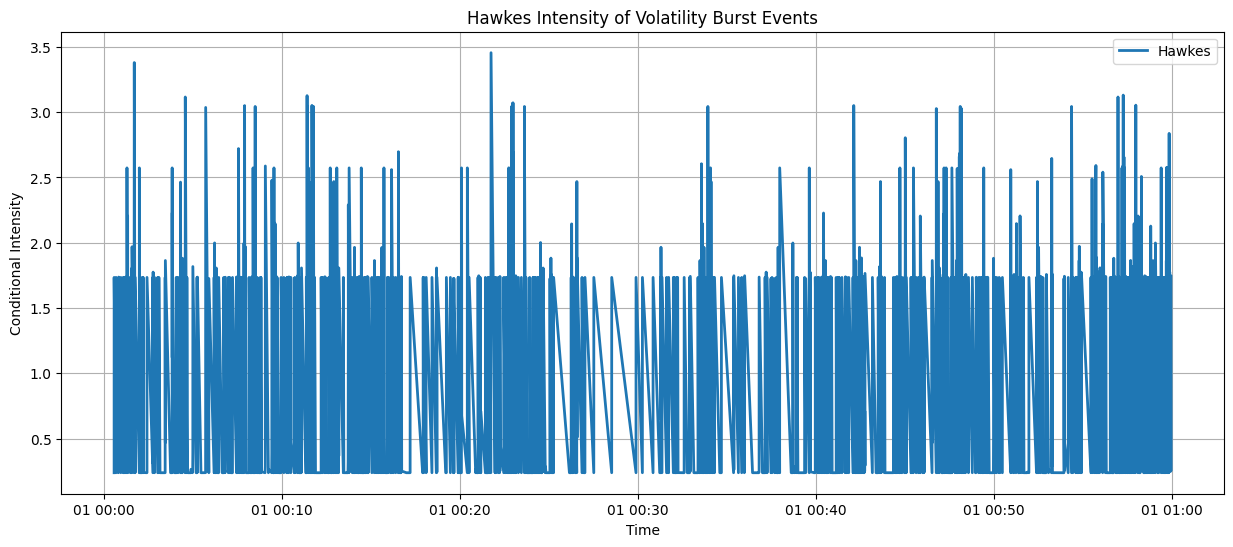

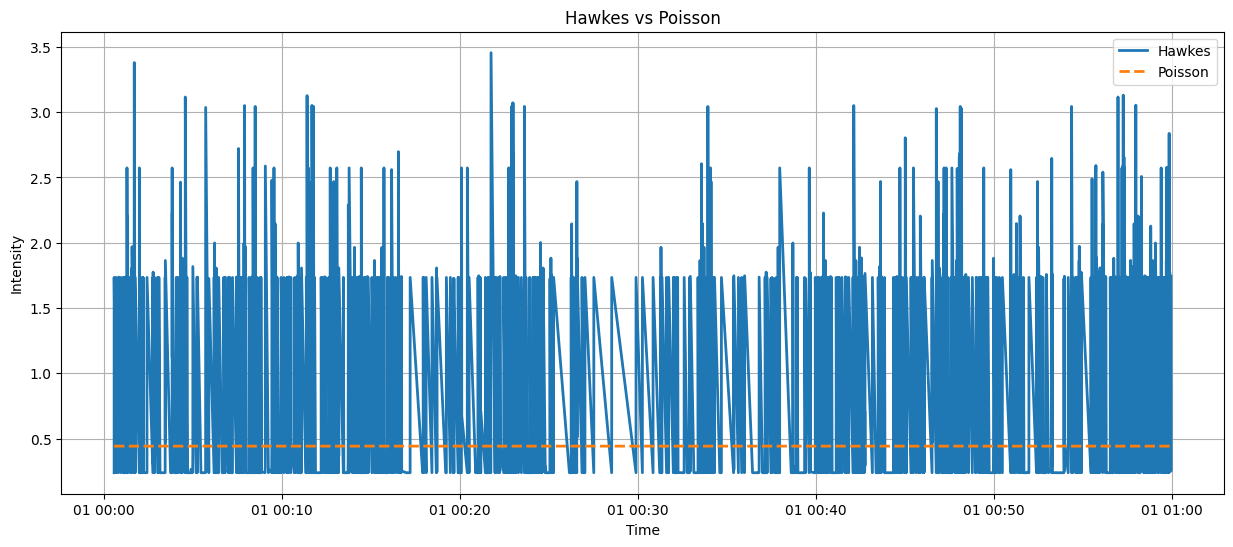

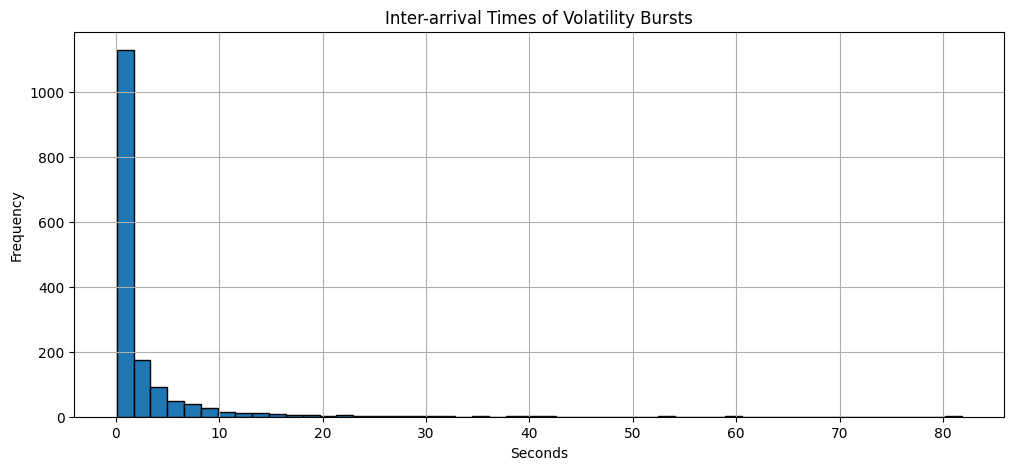


MODEL COMPARISON
     Model  LogLikelihood          AIC          BIC
0  Poisson   -2886.841004  5775.682008  5781.052868
1   Hawkes   -2215.231637  4436.463273  4452.575854

Likelihood Ratio Statistic : 1343.2187349825308

Branching Ratio (α/β): 0.4611712216944992

INTERPRETATION
✓ Stable Hawkes Process (α/β < 1)
✓ Hawkes outperforms Poisson based on AIC.
✓ Hawkes outperforms Poisson based on BIC.
✓ Hawkes model is statistically superior according to the Likelihood Ratio Test.

Volatility Burst Detection Project Completed Successfully.


In [2]:
# ==========================================================
# PART 2
# HAWKES INTENSITY
# ==========================================================

n = len(event_times)

R = np.zeros(n)

hawkes_intensity = np.zeros(n)

hawkes_intensity[0] = mu_hat

for i in range(1, n):

    dt = event_times[i] - event_times[i-1]

    R[i] = np.exp(-beta_hat * dt) * (1 + R[i-1])

    hawkes_intensity[i] = mu_hat + alpha_hat * R[i]

events["hawkes_intensity"] = hawkes_intensity

print("Hawkes intensity computed successfully.")

# ==========================================================
# POISSON MODEL
# ==========================================================

poisson_lambda = len(event_times) / T

events["poisson_intensity"] = poisson_lambda

print("Poisson Intensity :", poisson_lambda)

# ==========================================================
# SUMMARY
# ==========================================================

summary = pd.DataFrame({

    "Metric":[
        "Number of Events",
        "Observation Time",
        "Estimated μ",
        "Estimated α",
        "Estimated β",
        "Poisson λ"
    ],

    "Value":[
        len(event_times),
        T,
        mu_hat,
        alpha_hat,
        beta_hat,
        poisson_lambda
    ]

})

print(summary)

# ==========================================================
# HAWKES INTENSITY PLOT
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    events["timestamp"],
    events["hawkes_intensity"],
    linewidth=2,
    label="Hawkes"
)

plt.title("Hawkes Intensity of Volatility Burst Events")

plt.xlabel("Time")

plt.ylabel("Conditional Intensity")

plt.grid(True)

plt.legend()

plt.show()

# ==========================================================
# HAWKES VS POISSON
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    events["timestamp"],
    events["hawkes_intensity"],
    linewidth=2,
    label="Hawkes"
)

plt.plot(
    events["timestamp"],
    events["poisson_intensity"],
    "--",
    linewidth=2,
    label="Poisson"
)

plt.title("Hawkes vs Poisson")

plt.xlabel("Time")

plt.ylabel("Intensity")

plt.grid(True)

plt.legend()

plt.show()

# ==========================================================
# INTER-ARRIVAL TIMES
# ==========================================================

plt.figure(figsize=(12,5))

plt.hist(
    np.diff(event_times),
    bins=50,
    edgecolor="black"
)

plt.title("Inter-arrival Times of Volatility Bursts")

plt.xlabel("Seconds")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# ==========================================================
# MODEL COMPARISON
# ==========================================================

R = np.zeros(n)

for i in range(1, n):

    dt = event_times[i] - event_times[i-1]

    R[i] = np.exp(-beta_hat * dt) * (1 + R[i-1])

hawkes_intensity = mu_hat + alpha_hat * R

hawkes_loglik = np.sum(np.log(hawkes_intensity))

hawkes_loglik -= (

    mu_hat * T +

    (alpha_hat / beta_hat) *

    np.sum(

        1 -

        np.exp(

            -beta_hat *

            (T - event_times)

        )

    )

)

lambda_hat = len(event_times) / T

poisson_loglik = (

    len(event_times) *

    np.log(lambda_hat)

    -

    lambda_hat * T

)

hawkes_aic = 2*3 - 2*hawkes_loglik

poisson_aic = 2*1 - 2*poisson_loglik

hawkes_bic = np.log(len(event_times))*3 - 2*hawkes_loglik

poisson_bic = np.log(len(event_times))*1 - 2*poisson_loglik

lrt = 2*(hawkes_loglik - poisson_loglik)

comparison = pd.DataFrame({

    "Model":[
        "Poisson",
        "Hawkes"
    ],

    "LogLikelihood":[
        poisson_loglik,
        hawkes_loglik
    ],

    "AIC":[
        poisson_aic,
        hawkes_aic
    ],

    "BIC":[
        poisson_bic,
        hawkes_bic
    ]

})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(comparison)

print("\nLikelihood Ratio Statistic :", lrt)

# ==========================================================
# BRANCHING RATIO
# ==========================================================

branching_ratio = alpha_hat / beta_hat

print("\nBranching Ratio (α/β):", branching_ratio)

# ==========================================================
# INTERPRETATION
# ==========================================================

print("\n==============================")
print("INTERPRETATION")
print("==============================")

if branching_ratio < 1:
    print("✓ Stable Hawkes Process (α/β < 1)")
else:
    print("⚠ Unstable Hawkes Process")

if hawkes_aic < poisson_aic:
    print("✓ Hawkes outperforms Poisson based on AIC.")

if hawkes_bic < poisson_bic:
    print("✓ Hawkes outperforms Poisson based on BIC.")

if lrt > 3.84:
    print("✓ Hawkes model is statistically superior according to the Likelihood Ratio Test.")

print("\nVolatility Burst Detection Project Completed Successfully.")